In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv("../dataset/diabetic_data.csv")

print(df.shape)
df.head()

(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
print(df.head())

   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No                   No

In [5]:
# Check unique values
print(df['readmitted'].unique())

# Convert to 2 classes
df['readmitted'] = df['readmitted'].replace({
    'NO': 0,
    '>30': 1,
    '<30': 1
})

# Verify
print(df['readmitted'].value_counts())

<StringArray>
['NO', '>30', '<30']
Length: 3, dtype: str
readmitted
0    54864
1    46902
Name: count, dtype: int64


In [6]:
X = df.drop('readmitted', axis=1)
y = df['readmitted']

In [7]:
print(df['readmitted'].value_counts())

readmitted
0    54864
1    46902
Name: count, dtype: int64


In [8]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

NameError: name 'X_train' is not defined

In [ ]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    iterations=1000,
    depth=8,
    learning_rate=0.03,
    loss_function='Logloss',
    random_seed=42,
    verbose=100
)

In [ ]:
train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

[       encounter_id  patient_nbr             race  gender      age weight  \
 25118      84335988       472806  AfricanAmerican  Female  [50-60)      ?   
 63601     176921358    105754149        Caucasian  Female  [70-80)      ?   
 19781      70254918     23805477        Caucasian    Male  [60-70)      ?   
 94149     344841728     42193440        Caucasian    Male  [80-90)      ?   
 68161     192102114     85182138        Caucasian  Female  [70-80)      ?   
 ...             ...          ...              ...     ...      ...    ...   
 98467     401394866     35743986                ?    Male  [70-80)      ?   
 88388     284093148     98894529        Caucasian    Male  [50-60)      ?   
 8538       38472216       269073  AfricanAmerican    Male  [50-60)      ?   
 75317     225706236     90838404        Caucasian    Male  [60-70)      ?   
 5497       28473204       730935        Caucasian    Male  [50-60)      ?   
 
        admission_type_id  discharge_disposition_id  admission

In [ ]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  str   
 3   gender                    101766 non-null  str   
 4   age                       101766 non-null  str   
 5   weight                    101766 non-null  str   
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  str   
 11  medical_specialty         101766 non-null  str   
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_medications

In [ ]:
print((df ==  "?").sum())


encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum                   0
A1Cresult                       0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [ ]:
import numpy as np

df.replace("?", np.nan, inplace=True)

print(df.isnull().sum())

encounter_id                    0
patient_nbr                     0
race                         2273
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                  40256
medical_specialty           49949
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                         21
diag_2                        358
diag_3                       1423
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [ ]:
df["race"] = df["race"].fillna("Unknown")
df["payer_code"] = df["payer_code"].fillna("Unknown")
df["medical_specialty"] = df["medical_specialty"].fillna("Unknown")
df["diag_1"] = df["diag_1"].fillna("Unknown")
df["diag_2"] = df["diag_2"].fillna("Unknown")
df["diag_3"] = df["diag_3"].fillna("Unknown")

In [ ]:
print(df.isnull().sum())

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                      98569
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [ ]:
print(df.duplicated().sum())

0


In [ ]:
print(df["readmitted"].value_counts())

readmitted
0    54864
1    46902
Name: count, dtype: int64


In [ ]:
df["readmitted"] = df["readmitted"].replace({
    "NO": 0,
    ">30": 1,
    "<30": 2
})

print(df["readmitted"].value_counts())

readmitted
0    54864
1    46902
Name: count, dtype: int64


In [ ]:
df.to_csv("../dataset/cleaned_diabetic_data.csv", index=False)

print("Preprocessing completed successfully!")

Preprocessing completed successfully!


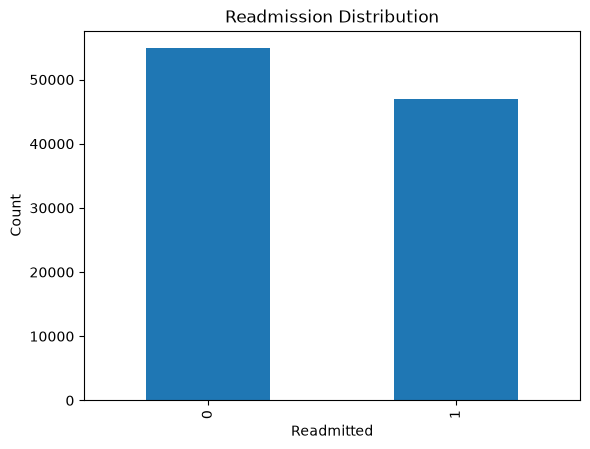

In [ ]:
import matplotlib.pyplot as plt

# Readmitted distribution
df["readmitted"].value_counts().plot(kind="bar")
plt.title("Readmission Distribution")
plt.xlabel("Readmitted")
plt.ylabel("Count")
plt.show()

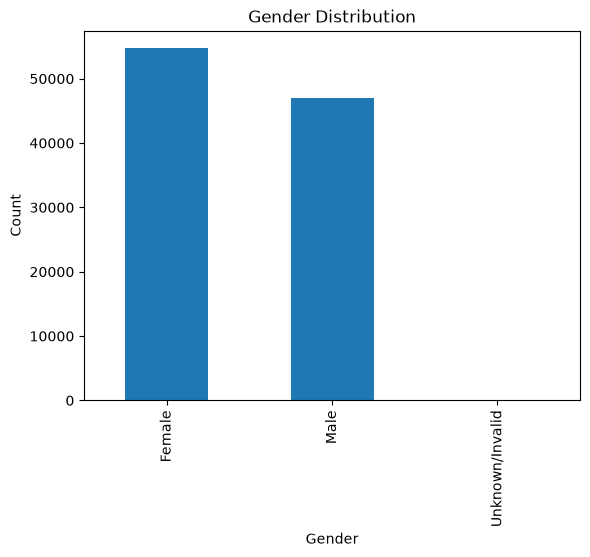

In [ ]:
import matplotlib.pyplot as plt

df["gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

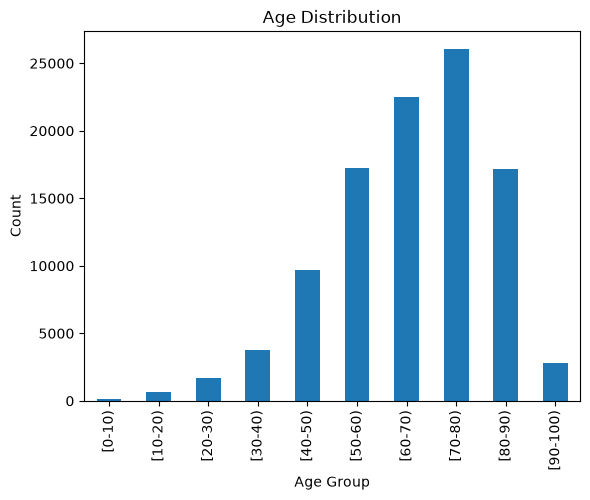

In [ ]:
df["age"].value_counts().sort_index().plot(kind="bar")
plt.title("Age Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

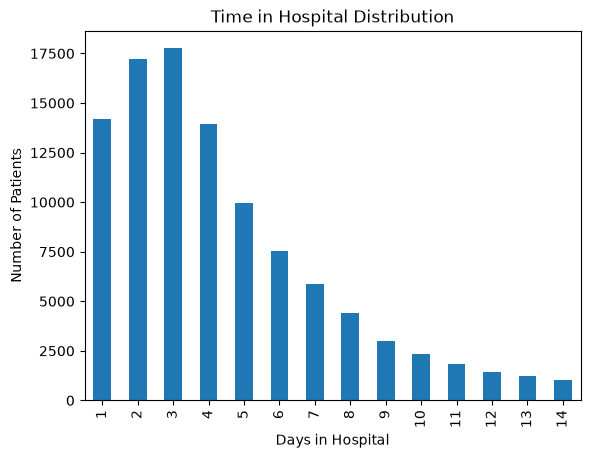

In [ ]:
df["time_in_hospital"].value_counts().sort_index().plot(kind="bar")
plt.title("Time in Hospital Distribution")
plt.xlabel("Days in Hospital")
plt.ylabel("Number of Patients")
plt.show()

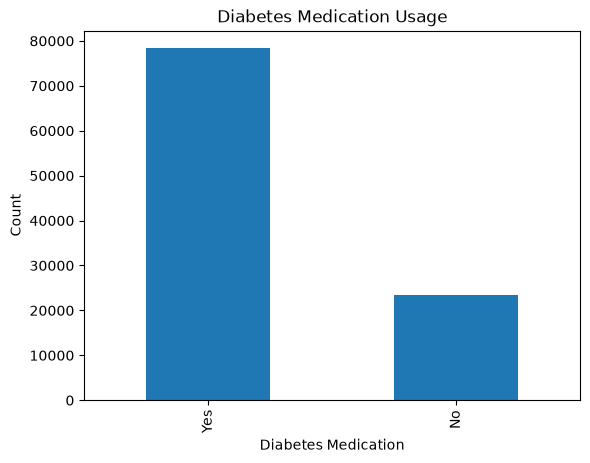

In [ ]:
df["diabetesMed"].value_counts().plot(kind="bar")
plt.title("Diabetes Medication Usage")
plt.xlabel("Diabetes Medication")
plt.ylabel("Count")
plt.show()

In [ ]:
df.to_csv("../dataset/cleaned_diabetic_data.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [ ]:
import pandas as pd

df = pd.read_csv("../dataset/cleaned_diabetic_data.csv")

print(df.head())

   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)    NaN   
1        149190     55629189        Caucasian  Female  [10-20)    NaN   
2         64410     86047875  AfricanAmerican  Female  [20-30)    NaN   
3        500364     82442376        Caucasian    Male  [30-40)    NaN   
4         16680     42519267        Caucasian    Male  [40-50)    NaN   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No                   No

In [ ]:
import pandas as pd

df = pd.read_csv("../dataset/cleaned_diabetic_data.csv")
print(df.shape)

(101766, 50)


In [ ]:
from sklearn.preprocessing import LabelEncoder

X = df.drop("readmitted", axis=1)
y = df["readmitted"]

for col in X.select_dtypes(include=["object", "string"]).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

y = LabelEncoder().fit_transform(y)

print(X.shape)
print(y.shape)

(101766, 49)
(101766,)


In [ ]:
X = df.drop("readmitted", axis=1)

y = df["readmitted"]

In [ ]:
print(X.shape)
print(y.shape)

(101766, 49)
(101766,)


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()

In [ ]:
for col in X.select_dtypes(include="object").columns:
    X[col] = le.fit_transform(X[col].astype(str))

C:\Users\Latha\AppData\Local\Temp\ipykernel_20728\477515344.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include="object").columns:


In [ ]:
y = LabelEncoder().fit_transform(y)

In [ ]:
print(X.head())
print(y[:10])

   encounter_id  patient_nbr  race  gender  age  weight  admission_type_id  \
0       2278392      8222157     2       0    0       9                  6   
1        149190     55629189     2       0    1       9                  1   
2         64410     86047875     0       0    2       9                  1   
3        500364     82442376     2       1    3       9                  1   
4         16680     42519267     2       1    4       9                  1   

   discharge_disposition_id  admission_source_id  time_in_hospital  ...  \
0                        25                    1                 1  ...   
1                         1                    7                 3  ...   
2                         1                    7                 2  ...   
3                         1                    7                 2  ...   
4                         1                    7                 1  ...   

   examide  citoglipton  insulin  glyburide-metformin  glipizide-metformin  \
0 

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(81412, 49)
(20354, 49)
(81412,)
(20354,)


In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss"
)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)



Accuracy: 0.6719072418197897
Accuracy (%): 67.19072418197896


In [ ]:
df['readmitted'].value_counts()

readmitted
0    54864
1    46902
Name: count, dtype: int64

In [ ]:
df['readmitted'] = df['readmitted'].replace({
    '<30':'Yes',
    '>30':'Yes',
    'NO':'No'
})

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

C:\Users\Latha\AppData\Local\Temp\ipykernel_20728\152405143.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('readmitted', axis=1)
y = df['readmitted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.2,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy*100)

Accuracy: 67.3332023189545


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

In [25]:
from xgboost import XGBClassifier

model = XGBClassifier(...)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print(accuracy)

c:\Users\Latha\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\core.py:550: FutureWarning: Pass `objective` as keyword args.
  warnings.warn(msg, FutureWarning)


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:race: str, gender: str, age: str, weight: str, payer_code: str, medical_specialty: str, diag_1: str, diag_2: str, diag_3: str, max_glu_serum: str, A1Cresult: str, metformin: str, repaglinide: str, nateglinide: str, chlorpropamide: str, glimepiride: str, acetohexamide: str, glipizide: str, glyburide: str, tolbutamide: str, pioglitazone: str, rosiglitazone: str, acarbose: str, miglitol: str, troglitazone: str, tolazamide: str, examide: str, citoglipton: str, insulin: str, glyburide-metformin: str, glipizide-metformin: str, glimepiride-pioglitazone: str, metformin-rosiglitazone: str, metformin-pioglitazone: str, change: str, diabetesMed: str

In [26]:
print(X_train.select_dtypes(include=['object']).columns)

Index(['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty',
       'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed'],
      dtype='str')


C:\Users\Latha\AppData\Local\Temp\ipykernel_13844\1115170628.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X_train.select_dtypes(include=['object']).columns)


In [28]:
print(X_train.select_dtypes(include=['object']).columns)

Index(['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty',
       'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin',
       'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
       'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed'],
      dtype='str')


C:\Users\Latha\AppData\Local\Temp\ipykernel_13844\1115170628.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X_train.select_dtypes(include=['object']).columns)


In [29]:
print(X_train.dtypes)
print(y_train.dtypes)

encounter_id                int64
patient_nbr                 int64
race                          str
gender                        str
age                           str
weight                        str
admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
time_in_hospital            int64
payer_code                    str
medical_specialty             str
num_lab_procedures          int64
num_procedures              int64
num_medications             int64
number_outpatient           int64
number_emergency            int64
number_inpatient            int64
diag_1                        str
diag_2                        str
diag_3                        str
number_diagnoses            int64
max_glu_serum                 str
A1Cresult                     str
metformin                     str
repaglinide                   str
nateglinide                   str
chlorpropamide                str
glimepiride                   str
acetohexamide 

In [30]:
print(X_train.isnull().sum().sum())
print(y_train.isnull().sum())

144908
0


In [31]:
missing = X_train.isnull().sum()
print(missing[missing > 0])

max_glu_serum    77130
A1Cresult        67778
dtype: int64


In [32]:
X_train["max_glu_serum"] = X_train["max_glu_serum"].fillna("None")
X_train["A1Cresult"] = X_train["A1Cresult"].fillna("None")

X_test["max_glu_serum"] = X_test["max_glu_serum"].fillna("None")
X_test["A1Cresult"] = X_test["A1Cresult"].fillna("None")

In [33]:
print(X_train[["max_glu_serum", "A1Cresult"]].dtypes)

max_glu_serum    str
A1Cresult        str
dtype: object


In [34]:
from sklearn.preprocessing import LabelEncoder

le_glu = LabelEncoder()
le_a1c = LabelEncoder()

X_train["max_glu_serum"] = le_glu.fit_transform(X_train["max_glu_serum"])
X_test["max_glu_serum"] = le_glu.transform(X_test["max_glu_serum"])

X_train["A1Cresult"] = le_a1c.fit_transform(X_train["A1Cresult"])
X_test["A1Cresult"] = le_a1c.transform(X_test["A1Cresult"])

In [35]:
print(X_train[["max_glu_serum","A1Cresult"]].dtypes)

max_glu_serum    int64
A1Cresult        int64
dtype: object


In [36]:
model.fit(X_train, y_train)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:race: str, gender: str, age: str, weight: str, payer_code: str, medical_specialty: str, diag_1: str, diag_2: str, diag_3: str, metformin: str, repaglinide: str, nateglinide: str, chlorpropamide: str, glimepiride: str, acetohexamide: str, glipizide: str, glyburide: str, tolbutamide: str, pioglitazone: str, rosiglitazone: str, acarbose: str, miglitol: str, troglitazone: str, tolazamide: str, examide: str, citoglipton: str, insulin: str, glyburide-metformin: str, glipizide-metformin: str, glimepiride-pioglitazone: str, metformin-rosiglitazone: str, metformin-pioglitazone: str, change: str, diabetesMed: str

In [37]:
print(X_train.select_dtypes(include=['object']).columns.tolist())

['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


C:\Users\Latha\AppData\Local\Temp\ipykernel_13844\3912895484.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X_train.select_dtypes(include=['object']).columns.tolist())


In [38]:
print(X_train.dtypes.value_counts())

str      34
int64    15
Name: count, dtype: int64


In [39]:
print(X_train.select_dtypes(include=['object', 'string']).columns.tolist())

['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


In [40]:
from sklearn.preprocessing import LabelEncoder

for col in X_train.select_dtypes(include=['object', 'string']).columns:
    le = LabelEncoder()

    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

ValueError: y contains previously unseen labels: 'Perinatology'

In [41]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

for col in X_train.select_dtypes(include=['object', 'string']).columns:
    le = LabelEncoder()

    all_values = pd.concat([X_train[col], X_test[col]], axis=0).astype(str)

    le.fit(all_values)

    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

In [42]:
model.fit(X_train, y_train)

XGBoostError: [22:34:44] C:\actions-runner\_work\xgboost\xgboost\src\objective\objective.cc:27: Unknown objective function: `Ellipsis`
Objective candidate: rank:ndcg
Objective candidate: rank:pairwise
Objective candidate: rank:map
Objective candidate: survival:aft
Objective candidate: binary:hinge
Objective candidate: multi:softmax
Objective candidate: multi:softprob
Objective candidate: reg:quantileerror
Objective candidate: reg:squarederror
Objective candidate: reg:logistic
Objective candidate: binary:logistic
Objective candidate: binary:logitraw
Objective candidate: reg:gamma
Objective candidate: reg:linear
Objective candidate: reg:squaredlogerror
Objective candidate: reg:pseudohubererror
Objective candidate: reg:expectileerror
Objective candidate: count:poisson
Objective candidate: survival:cox
Objective candidate: reg:tweedie
Objective candidate: reg:absoluteerror


In [43]:
from xgboost import XGBClassifier

model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

In [44]:
model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [45]:
print(y_train.unique())

[0 1]


In [46]:
from xgboost import XGBClassifier

model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

In [47]:
model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [48]:
y_pred = model.predict(X_test)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:medical_specialty: str

In [49]:
print(X_train["medical_specialty"].dtype)
print(X_test["medical_specialty"].dtype)

int64
str


In [50]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

le = LabelEncoder()

all_values = pd.concat(
    [X_train["medical_specialty"], X_test["medical_specialty"]],
    axis=0
).astype(str)

le.fit(all_values)

X_train["medical_specialty"] = le.transform(X_train["medical_specialty"].astype(str))
X_test["medical_specialty"] = le.transform(X_test["medical_specialty"].astype(str))

In [51]:
print(X_train["medical_specialty"].dtype)

int64


In [52]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [53]:
model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [54]:
y_pred = model.predict(X_test)

In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

ValueError: Classification metrics can't handle a mix of unknown and binary targets

In [56]:
print(y_test.dtype)
print(type(y_test))

print(y_pred.dtype)
print(type(y_pred))

print(y_test[:10])
print(y_pred[:10])

object
<class 'pandas.Series'>
int64
<class 'numpy.ndarray'>
35956    0
60927    0
79920    0
50078    1
44080    1
4727     0
29944    0
84575    1
59479    1
56742    1
Name: readmitted, dtype: object
[0 0 1 1 1 0 0 1 0 1]


In [57]:
print(y_test.unique())
print(set(y_pred))

[0 1]
{np.int64(0), np.int64(1)}


In [58]:
print(type(y_test))
print(y_test.shape)

print(type(y_pred))
print(y_pred.shape)

<class 'pandas.Series'>
(20354,)
<class 'numpy.ndarray'>
(20354,)


In [59]:
y_test = y_test.squeeze()

In [60]:
import numpy as np

y_test = np.ravel(y_test)

In [61]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

ValueError: Classification metrics can't handle a mix of unknown and binary targets

In [62]:
print("y_test type:", type(y_test))
print("y_test dtype:", y_test.dtype)
print("y_test shape:", y_test.shape)

print("y_pred type:", type(y_pred))
print("y_pred dtype:", y_pred.dtype)
print("y_pred shape:", y_pred.shape)

print(y_test[:5])
print(y_pred[:5])

y_test type: <class 'numpy.ndarray'>
y_test dtype: object
y_test shape: (20354,)
y_pred type: <class 'numpy.ndarray'>
y_pred dtype: int64
y_pred shape: (20354,)
[0 0 0 1 1]
[0 0 1 1 1]


In [63]:
from sklearn.utils.multiclass import type_of_target

print(type_of_target(y_test))
print(type_of_target(y_pred))

unknown
binary


In [64]:
print(type(y_test))
print(y_test.dtype)
print(y_test.shape)

<class 'numpy.ndarray'>
object
(20354,)


In [65]:
print(y_test.head())

AttributeError: 'numpy.ndarray' object has no attribute 'head'

In [66]:
print(type(y_test))
print(y_test.dtype)
print(y_test.shape)
print(y_test[:10])

<class 'numpy.ndarray'>
object
(20354,)
[0 0 0 1 1 0 0 1 1 1]


In [67]:
print(type(y_pred))
print(y_pred.dtype)
print(y_pred.shape)
print(y_pred[:10])

<class 'numpy.ndarray'>
int64
(20354,)
[0 0 1 1 1 0 0 1 0 1]


In [68]:
print(y_pred.shape)

(20354,)


In [69]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Convert to integer arrays
y_test = np.array(y_test).astype(int)
y_pred = np.array(y_pred).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='binary'))
print("Recall   :", recall_score(y_test, y_pred, average='binary'))
print("F1 Score :", f1_score(y_test, y_pred, average='binary'))

Accuracy : 0.6675346369264027
Precision: 0.6516634050880626
Recall   : 0.6021059349074664
F1 Score : 0.625905246282271


In [70]:
df = df.drop(columns=["encounter_id", "patient_nbr"])

In [71]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

ValueError: Unknown label type: unknown. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

In [72]:
print(type(y_train))
print(y_train.dtype)
print(y_train.shape)
print(y_train[:10])

<class 'pandas.Series'>
object
(81412,)
24079    0
98079    1
6237     0
72208    0
33075    0
12913    0
81022    1
79358    0
60741    0
62297    1
Name: readmitted, dtype: object


In [73]:
from sklearn.utils.multiclass import type_of_target

print(type_of_target(y_train))

unknown


In [74]:
import numpy as np

y_train = np.asarray(y_train).astype(np.int64).reshape(-1)
y_test = np.asarray(y_test).astype(np.int64).reshape(-1)

print(type_of_target(y_train))

binary


In [75]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

In [76]:
model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=600,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.9
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [77]:
y_pred = model.predict(X_test)

In [78]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.6681242016311291
Precision: 0.6500737045016441
Recall   : 0.6097638800255265
F1 Score : 0.6292739147137918


In [79]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.72      0.70     10952
           1       0.65      0.61      0.63      9402

    accuracy                           0.67     20354
   macro avg       0.67      0.66      0.66     20354
weighted avg       0.67      0.67      0.67     20354



In [80]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]
roc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.7303108124811888


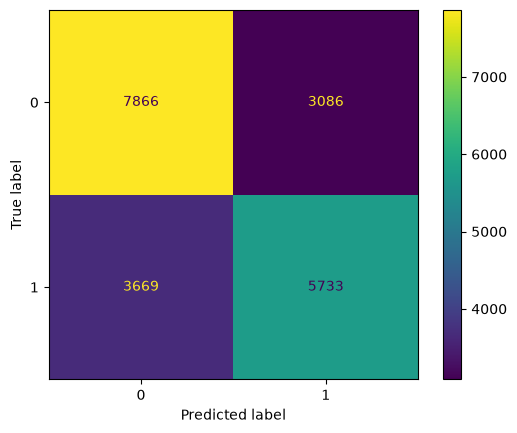

In [81]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [82]:
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Precision: 0.6500737045016441
Recall: 0.6097638800255265
F1 Score: 0.6292739147137918

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.72      0.70     10952
           1       0.65      0.61      0.63      9402

    accuracy                           0.67     20354
   macro avg       0.67      0.66      0.66     20354
weighted avg       0.67      0.67      0.67     20354



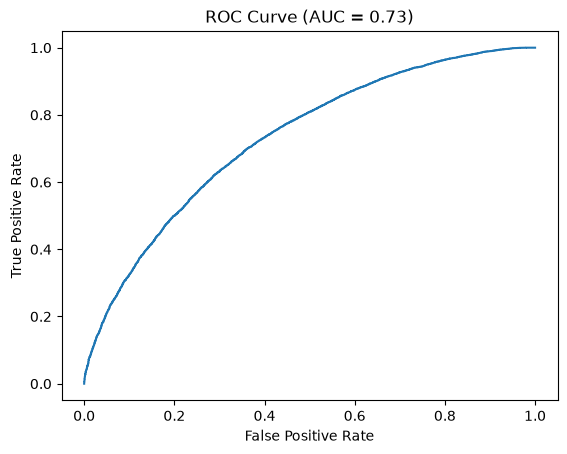

ROC-AUC Score: 0.7303108124811888


In [83]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc:.2f})")
plt.show()

print("ROC-AUC Score:", auc)

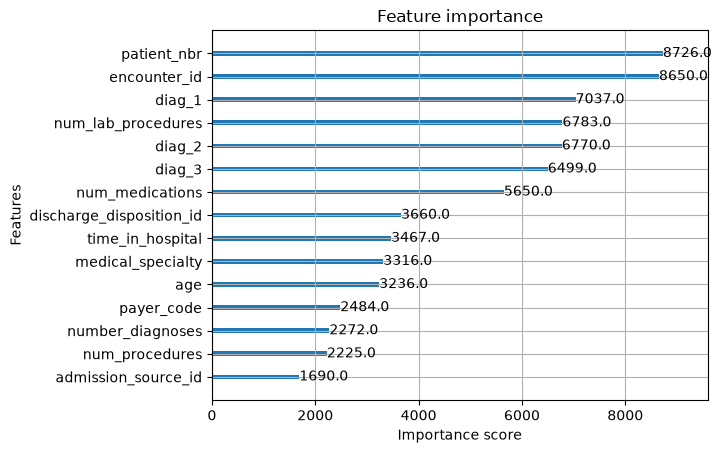

In [84]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(model, max_num_features=15)
plt.show()

In [85]:
df['readmitted'] = df['readmitted'].apply(
    lambda x: 0 if x == 'NO' else 1
)

In [87]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

for col in df_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

X = df_encoded.drop('readmitted', axis=1)
y = df_encoded['readmitted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

C:\Users\Latha\AppData\Local\Temp\ipykernel_13844\2577084220.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_encoded.select_dtypes(include='object').columns:


In [88]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    scale_pos_weight=1.2,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0], got [1]

In [89]:
print(y_train.value_counts())
print(y_test.value_counts())

readmitted
1    81412
Name: count, dtype: int64
readmitted
1    20354
Name: count, dtype: int64


In [90]:
print(df['readmitted'].value_counts())

readmitted
1    101766
Name: count, dtype: int64


In [91]:
df['readmitted'] = df['readmitted'].apply(
    lambda x: 0 if x == 'NO' else 1
)

print(df['readmitted'].value_counts())

readmitted
1    101766
Name: count, dtype: int64


In [92]:
X = df.drop('readmitted', axis=1)
y = df['readmitted']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(y_train.value_counts())

readmitted
1    81412
Name: count, dtype: int64


In [93]:
print(df['readmitted'].unique())

[1]


In [94]:
import pandas as pd

df = pd.read_csv("../dataset/cleaned_diabetic_data.csv")

print(df['readmitted'].value_counts())

readmitted
0    54864
1    46902
Name: count, dtype: int64


In [95]:
df['readmitted'] = df['readmitted'].apply(
    lambda x: 0 if x == 'NO' else 1
)

print(df['readmitted'].value_counts())

readmitted
1    101766
Name: count, dtype: int64


In [96]:
import pandas as pd

df = pd.read_csv("../dataset/cleaned_diabetic_data.csv")

print(df['readmitted'].value_counts())

readmitted
0    54864
1    46902
Name: count, dtype: int64


In [97]:
df['readmitted'] = df['readmitted'].apply(
    lambda x: 0 if x == 'NO' else 1
)

print(df['readmitted'].value_counts())

readmitted
1    101766
Name: count, dtype: int64


In [98]:
import pandas as pd

df = pd.read_csv("../dataset/diabetic_data.csv")

print(df['readmitted'].value_counts())

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


In [99]:
df['readmitted'] = df['readmitted'].apply(
    lambda x: 0 if x == 'NO' else 1
)

print(df['readmitted'].value_counts())

readmitted
0    54864
1    46902
Name: count, dtype: int64


In [100]:
df.replace("?", "Unknown", inplace=True)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),Unknown,6,25,1,1,...,No,No,No,No,No,No,No,No,No,0
1,149190,55629189,Caucasian,Female,[10-20),Unknown,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,1
2,64410,86047875,AfricanAmerican,Female,[20-30),Unknown,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,0
3,500364,82442376,Caucasian,Male,[30-40),Unknown,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,16680,42519267,Caucasian,Male,[40-50),Unknown,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),Unknown,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,1
101762,443847782,74694222,AfricanAmerican,Female,[80-90),Unknown,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,0
101763,443854148,41088789,Caucasian,Male,[70-80),Unknown,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,0
101764,443857166,31693671,Caucasian,Female,[80-90),Unknown,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,0


In [101]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col].astype(str))

C:\Users\Latha\AppData\Local\Temp\ipykernel_13844\3207929033.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [102]:
from sklearn.model_selection import train_test_split

X = df.drop("readmitted", axis=1)
y = df["readmitted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(y_train.value_counts())

readmitted
0    43891
1    37521
Name: count, dtype: int64


In [103]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Classification Report
print(classification_report(y_test, y_pred))

Accuracy: 0.6759359339687531
              precision    recall  f1-score   support

           0       0.69      0.73      0.71     10973
           1       0.66      0.62      0.64      9381

    accuracy                           0.68     20354
   macro avg       0.67      0.67      0.67     20354
weighted avg       0.68      0.68      0.67     20354

